# **Time Series Forecasting**

**Author:** Manuel Eugenio Morocho Cayamcela, PhD

A comprehensive walkthrough of classical statistical models, machine learning, and deep learning approaches for univariate time series forecasting, evaluated on the **Air Passengers dataset** (1949–1960, monthly international airline passengers).

## Requirements Installation

In [1]:
%pip install pandas numpy matplotlib seaborn statsmodels scikit-learn lightgbm prophet plotly pytorch-forecasting pytorch-lightning --quiet
%pip install tensorflow==2.16.2 --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Introduction to Time Series Analysis

A **time series** is a sequence of observations indexed in chronological order. Examples include stock prices, energy demand, weather measurements, and passenger counts.

**Time series forecasting** uses historical patterns to predict future values.

### Key Concepts

| Concept | Description |
|---|---|
| **Trend** | Long-term increase or decrease in the data |
| **Seasonality** | Repeating pattern at a fixed period (e.g., monthly, yearly) |
| **Stationarity** | Statistical properties (mean, variance) are constant over time |
| **Autocorrelation** | Correlation of a series with its own lagged values |

### Types of Forecasting

**Univariate:** A single time-dependent variable (e.g., monthly passengers → forecast next month's passengers).

**Multivariate:** Multiple interrelated variables where each depends on its own past and on the others.

### Model Families Covered in This Notebook

| Family | Models |
|---|---|
| Classical / Statistical | AR, MA, ARIMA, SARIMA, Exponential Smoothing (SES, Holt, Holt-Winters), Prophet |
| Machine Learning | LightGBM, XGBoost |
| Deep Learning | RNN, LSTM |
| Advanced DL | Temporal Fusion Transformer (TFT) |

## 2. Dataset — Air Passengers

The **Air Passengers** dataset records the monthly total of international airline passengers (in thousands) from January 1949 to December 1960. It is the canonical benchmark for time-series forecasting because it exhibits:

- A clear **upward trend**
- Strong **annual seasonality** (summer peaks)
- **Multiplicative structure**: variance grows with the level

We will *hold out* the last 24 months (2 years) as the **test set** and train on the first 120 months (10 years).

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv('/Users/eugenio/Documents/Notebooks_ArtificialIntelligence/Datasets/air_passengers.csv', parse_dates=['Month'])
df = df.rename(columns={'#Passengers': 'Passengers'})
df = df.set_index('Month').asfreq('MS')   # Monthly Start frequency. Other options: 'M' (Month End), 'D' (Daily), 'H' (Hourly), etc.

print(f"Shape: {df.shape}")
print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}")
print(f"\nFirst rows:")
df.head(10)

Shape: (144, 1)
Date range: 1949-01-01 → 1960-12-01

First rows:


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [ ]:
# ── Train / test split ────────────────────────────────────────────────────
TEST_MONTHS = 24
train = df.iloc[:-TEST_MONTHS] # :-TEST_MONTHS means "all rows except the last TEST_MONTHS rows"
test  = df.iloc[-TEST_MONTHS:] # -TEST_MONTHS means "the last TEST_MONTHS rows"

print(f"Train: {len(train)} months  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test : {len(test)}  months  ({test.index[0].date()}  → {test.index[-1].date()})")

Train: 120 months  (1949-01-01 → 1958-12-01)
Test : 24  months  (1959-01-01  → 1960-12-01)


## 3. Exploratory Data Analysis (EDA)

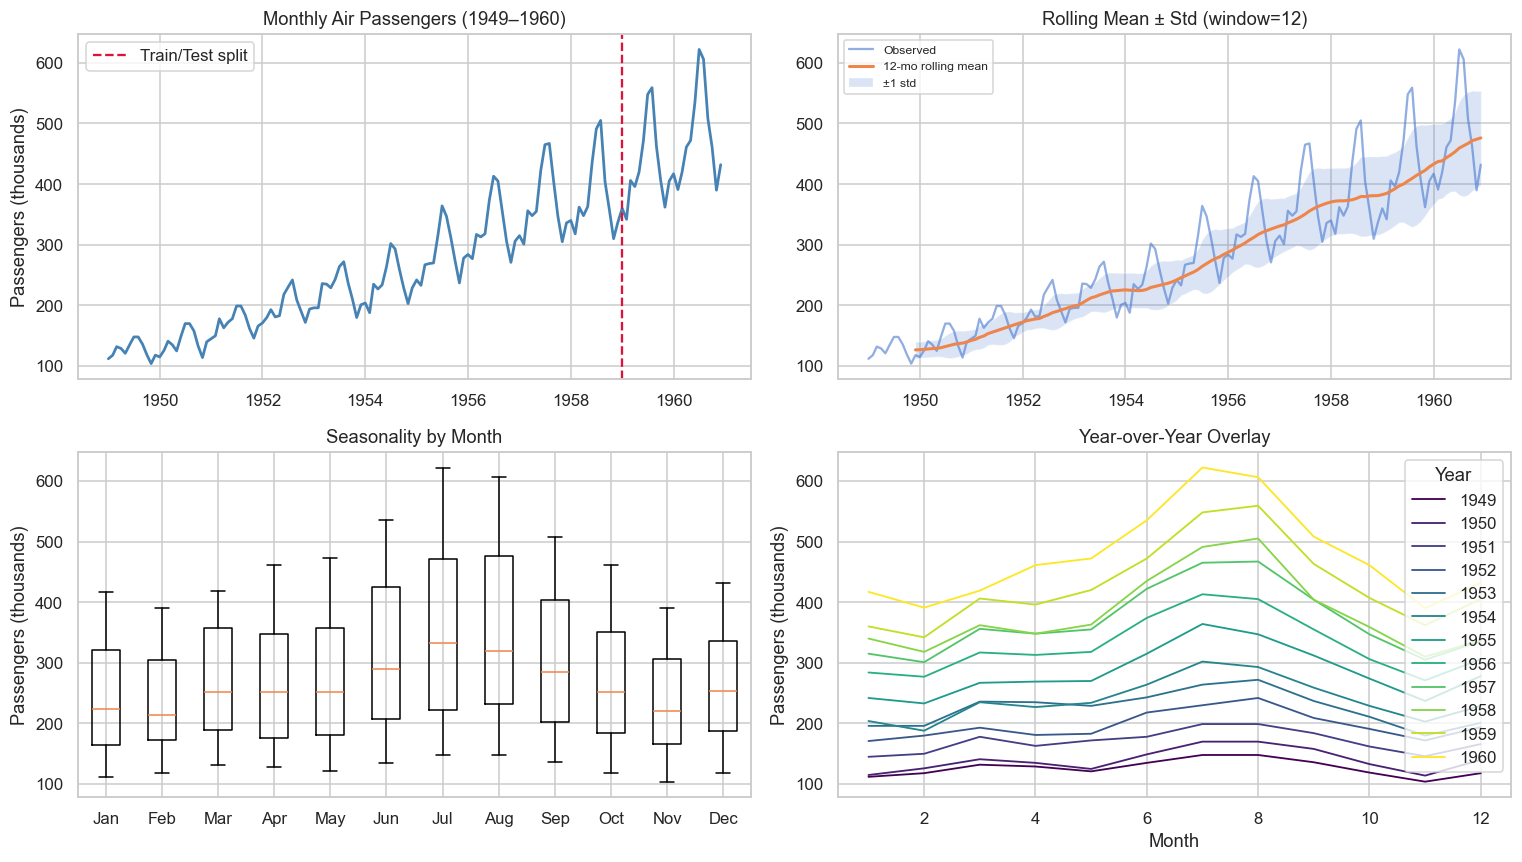

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Raw series
axes[0, 0].plot(df.index, df['Passengers'], color='steelblue', lw=1.8)
axes[0, 0].axvline(test.index[0], color='crimson', ls='--', label='Train/Test split')
axes[0, 0].set_title('Monthly Air Passengers (1949–1960)')
axes[0, 0].set_ylabel('Passengers (thousands)')
axes[0, 0].legend()

# 2. Rolling statistics
roll = df['Passengers'].rolling(12)
axes[0, 1].plot(df['Passengers'], label='Observed', alpha=0.6)
axes[0, 1].plot(roll.mean(), label='12-mo rolling mean', lw=2) # Rolling mean with a 12-month window
axes[0, 1].fill_between(df.index, roll.mean() - roll.std(), roll.mean() + roll.std(),
                         alpha=0.2, label='±1 std')
axes[0, 1].set_title('Rolling Mean ± Std (window=12)')
axes[0, 1].legend(fontsize=8)

# 3. Monthly seasonality box plot
monthly = df.copy()
monthly['Month_num'] = monthly.index.month
axes[1, 0].boxplot([df['Passengers'][df.index.month == m] for m in range(1, 13)], # Create a list of 12 arrays, one for each month
                   labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[1, 0].set_title('Seasonality by Month')
axes[1, 0].set_ylabel('Passengers (thousands)')

# 4. Year-over-year
yearly = df.copy()
yearly['Year'] = yearly.index.year
pivot = yearly.pivot_table(values='Passengers', index=yearly.index.month, columns='Year') # Create a pivot table with months as rows and years as columns
pivot.plot(ax=axes[1, 1], legend=True, colormap='viridis', lw=1.2)
axes[1, 1].set_title('Year-over-Year Overlay')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Passengers (thousands)')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

## 4. Stationarity and Decomposition

### Augmented Dickey-Fuller Test

The **ADF test** checks the null hypothesis $H_0$: the series has a unit root (non-stationary).

$$
\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^{p} \delta_i \Delta y_{t-i} + \varepsilon_t
$$

- If **p-value < 0.05** → reject $H_0$ → series is stationary.
- If **p-value ≥ 0.05** → fail to reject → non-stationary, differencing needed.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name='Series'):
    result = adfuller(series.dropna())
    print(f"{'─'*45}")
    print(f"ADF test — {name}")
    print(f"  Statistic : {result[0]:.4f}")
    print(f"  p-value   : {result[1]:.4f}")
    print(f"  Lags used : {result[2]}")
    print(f"  Verdict   : {'✅ Stationary (p<0.05)' if result[1] < 0.05 else '❌ Non-stationary (p≥0.05)'}")

adf_report(df['Passengers'], 'Raw series')
adf_report(np.log(df['Passengers']).diff(1).dropna(), 'Log + 1st difference') # Log transform to stabilize variance, then first difference to remove trend and seasonality

─────────────────────────────────────────────
ADF test — Raw series
  Statistic : 0.8154
  p-value   : 0.9919
  Lags used : 13
  Verdict   : ❌ Non-stationary (p≥0.05)
─────────────────────────────────────────────
ADF test — Log + 1st difference
  Statistic : -2.7171
  p-value   : 0.0711
  Lags used : 14
  Verdict   : ❌ Non-stationary (p≥0.05)


### Seasonal Decomposition

We decompose the series into **trend**, **seasonal**, and **residual** components.

- **Additive model**: $y_t = T_t + S_t + R_t$ (constant variance)
- **Multiplicative model**: $y_t = T_t \times S_t \times R_t$ (variance grows with level)

Given that the amplitude of seasonality grows with the level, the **multiplicative** model is more appropriate here.

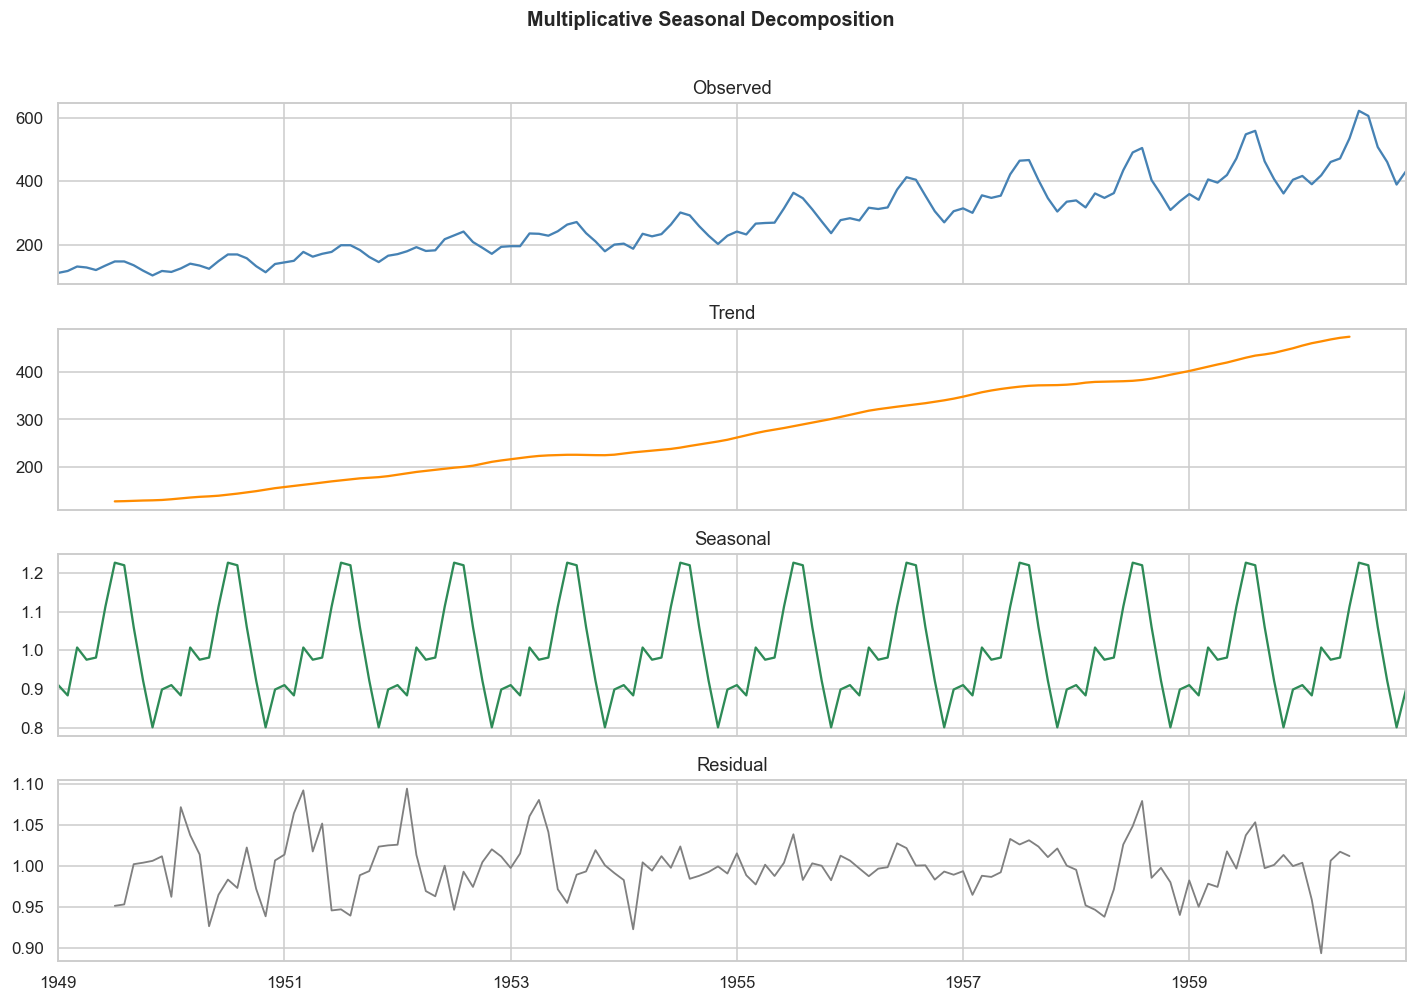

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
decomp = seasonal_decompose(df['Passengers'], model='multiplicative', period=12) # period=12 means we expect a yearly seasonality (12 months). For daily data with weekly seasonality, use period=7, etc.

decomp.observed.plot(ax=axes[0], title='Observed', color='steelblue', lw=1.5)
decomp.trend.plot(ax=axes[1], title='Trend', color='darkorange', lw=1.5)
decomp.seasonal.plot(ax=axes[2], title='Seasonal', color='seagreen', lw=1.5)
decomp.resid.plot(ax=axes[3], title='Residual', color='grey', lw=1.2)

for ax in axes:
    ax.set_xlabel('')
plt.suptitle('Multiplicative Seasonal Decomposition', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('decomposition.png', bbox_inches='tight')
plt.show()

## 5. Metrics

We evaluate each model on the **test set** using three metrics:

| Metric | Formula | Notes |
|---|---|---|
| MAE | $\frac{1}{n} \sum\|y_t - \hat{y}_t \|$ | Same unit as the series; easy to interpret |
| RMSE | $\sqrt{\frac{1}{n}\sum(y_t - \hat{y}_t)^2}$ | Penalises large errors more than MAE |
| MAPE | $\frac{100}{n}\sum\left|\frac{y_t - \hat{y}_t}{y_t}\right|$ | Scale-independent percentage error |

All results are accumulated in a summary table at the end.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(name, y_true, y_pred):
    """Compute MAE, RMSE, MAPE and store in results_list."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    results_list.append({'Model': name, 'MAE': round(mae, 2),
                         'RMSE': round(rmse, 2), 'MAPE (%)': round(mape, 2)})
    print(f"[{name}]  MAE={mae:.2f}  RMSE={rmse:.2f}  MAPE={mape:.2f}%")

results_list = []   # will be filled model by model

In [9]:
def plot_forecast(name, train, test, forecast, color='tomato'):
    """Plot train/test/forecast for a model."""
    plt.figure(figsize=(12, 4))
    plt.plot(train.index, train['Passengers'], label='Train', color='steelblue', lw=1.5)
    plt.plot(test.index,  test['Passengers'],  label='Actual (test)', color='seagreen', lw=1.5)
    plt.plot(test.index,  forecast,            label=f'Forecast — {name}',
             color=color, lw=1.8, ls='--')
    plt.title(f'Forecast: {name}', fontsize=12, fontweight='bold')
    plt.ylabel('Passengers (thousands)')
    plt.legend()
    plt.tight_layout()
    safe_name = name.replace(" ", "_").replace("/", "-")
    plt.savefig(f'forecast_{safe_name}.png', bbox_inches='tight')
    plt.show()


---
## 6. Classical Statistical Models

### 6.1 ARIMA — Autoregressive Integrated Moving Average

ARIMA $(p, d, q)$ combines three operations:

**AR $(p)$** — the series depends linearly on its own $p$ past values:
$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t$$

**I $(d)$** — the series is differenced $d$ times to achieve stationarity:
$$y'_t = y_t - y_{t-1}$$

**MA $(q)$** — the forecast error is modelled as a linear combination of past errors:
$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$

Combined ARIMA $(p,d,q)$:
$$\phi(B)(1-B)^d y_t = c + \theta(B)\varepsilon_t$$

where $B$ is the backshift operator ($B y_t = y_{t-1}$).

**Pros:** Interpretable, fast, well-understood.  
**Cons:** Assumes linearity; does not capture seasonality directly; requires stationarity.

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -541.534
Date:                Tue, 05 May 2026   AIC                           1093.069
Time:                        04:58:06   BIC                           1106.965
Sample:                    01-01-1949   HQIC                          1098.711
                         - 12-01-1958                                         
Covariance Type:                  opg                                         


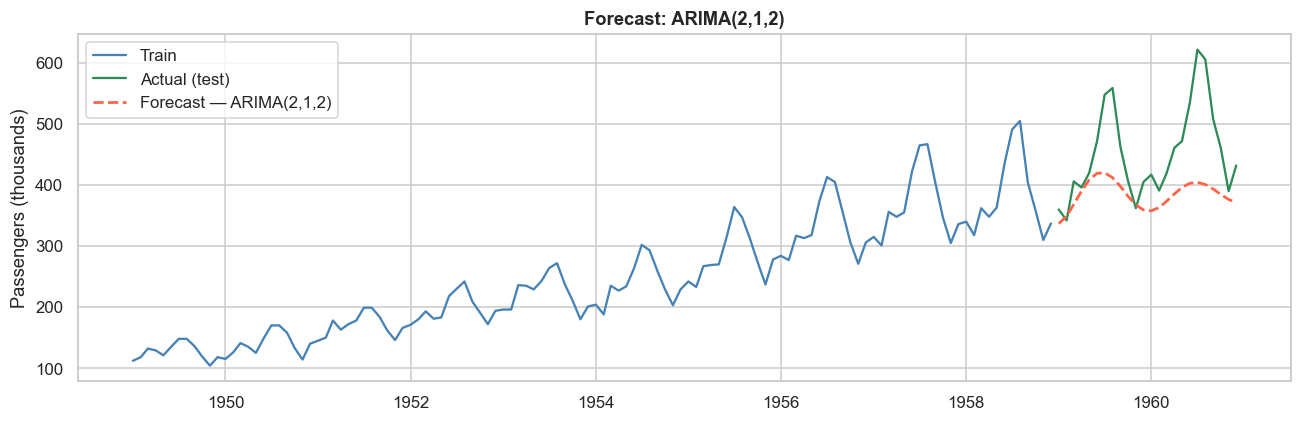

[ARIMA]  MAE=69.10  RMSE=90.69  MAPE=13.78%


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(2,1,2) — chosen by inspection of ACF/PACF
arima_model = ARIMA(train['Passengers'], order=(2, 1, 2)) # (2, 1, 2) means AR=2, I=1, MA=2. Try different values based on ACF/PACF plots or use auto_arima from pmdarima for automatic order selection.
arima_fit   = arima_model.fit()
print(arima_fit.summary().tables[0])

arima_forecast = arima_fit.forecast(steps=TEST_MONTHS)
arima_forecast.index = test.index

plot_forecast('ARIMA(2,1,2)', train, test, arima_forecast, color='tomato')
evaluate('ARIMA', test['Passengers'], arima_forecast)

### 6.2 SARIMA — Seasonal ARIMA

SARIMA $(p,d,q)(P,D,Q)_s$ extends ARIMA with a seasonal component at period $s$:

$$\Phi(B^s)\phi(B)(1-B^s)^D(1-B)^d y_t = \Theta(B^s)\theta(B)\varepsilon_t$$

Where $\Phi, \Theta$ are seasonal AR and MA polynomials.

For monthly data with annual seasonality: $s = 12$.

**Pros:** Handles seasonality explicitly; interpretable parameters.  
**Cons:** More hyperparameters to tune; sensitive to misspecification.

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -348.860
Date:                            Tue, 05 May 2026   AIC                            707.720
Time:                                    04:58:06   BIC                            720.383
Sample:                                01-01-1949   HQIC                           712.833
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         


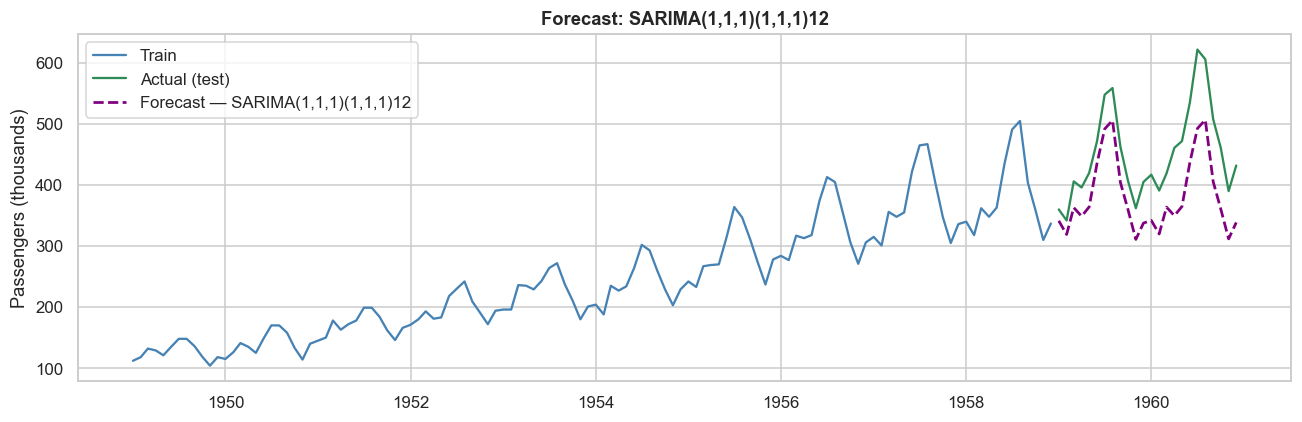

[SARIMA]  MAE=69.90  RMSE=75.63  MAPE=15.22%


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX # SARIMA = Seasonal ARIMA, where we add seasonal terms to capture seasonality patterns. The seasonal_order=(P,D,Q,s) has the same meaning as order=(p,d,q) but for the seasonal component, and s is the length of the seasonality (e.g., 12 for monthly data with yearly seasonality).

sarima_model = SARIMAX(train['Passengers'],
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
                       # exog=... can be used to add external regressors (e.g., holidays, promotions, etc.) to the model. Just make sure to provide the same exogenous variables for both training and forecasting (with the same number of rows as train/test). 
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary().tables[0])

sarima_forecast = sarima_fit.forecast(steps=TEST_MONTHS)
sarima_forecast.index = test.index

plot_forecast('SARIMA(1,1,1)(1,1,1)12', train, test, sarima_forecast, color='purple')
evaluate('SARIMA', test['Passengers'], sarima_forecast)

### 6.3 Exponential Smoothing Family

Exponential smoothing assigns **exponentially decreasing weights** to past observations. There are three levels of complexity:

#### Simple Exponential Smoothing (SES)
Suitable for series **without trend or seasonality**:
$$\hat{y}_{t+1} = \alpha y_t + (1 - \alpha)\hat{y}_t, \quad 0 < \alpha < 1$$

#### Holt's Linear Method (Double Exponential Smoothing)
Adds a **trend** component $b_t$:
$$l_t = \alpha y_t + (1-\alpha)(l_{t-1} + b_{t-1})$$
$$b_t = \beta(l_t - l_{t-1}) + (1-\beta)b_{t-1}$$
$$\hat{y}_{t+h} = l_t + h b_t$$

#### Holt-Winters Triple Exponential Smoothing
Adds a **seasonal** component $s_t$ (multiplicative form):
$$l_t = \alpha \frac{y_t}{s_{t-m}} + (1-\alpha)(l_{t-1} + b_{t-1})$$
$$b_t = \beta(l_t - l_{t-1}) + (1-\beta)b_{t-1}$$
$$s_t = \gamma \frac{y_t}{l_t} + (1-\gamma)s_{t-m}$$
$$\hat{y}_{t+h} = (l_t + hb_t)\cdot s_{t-m+h}$$

**Pros:** Intuitive, fast, handles trend and seasonality.  
**Cons:** Assumes fixed structure; struggles with abrupt changes.

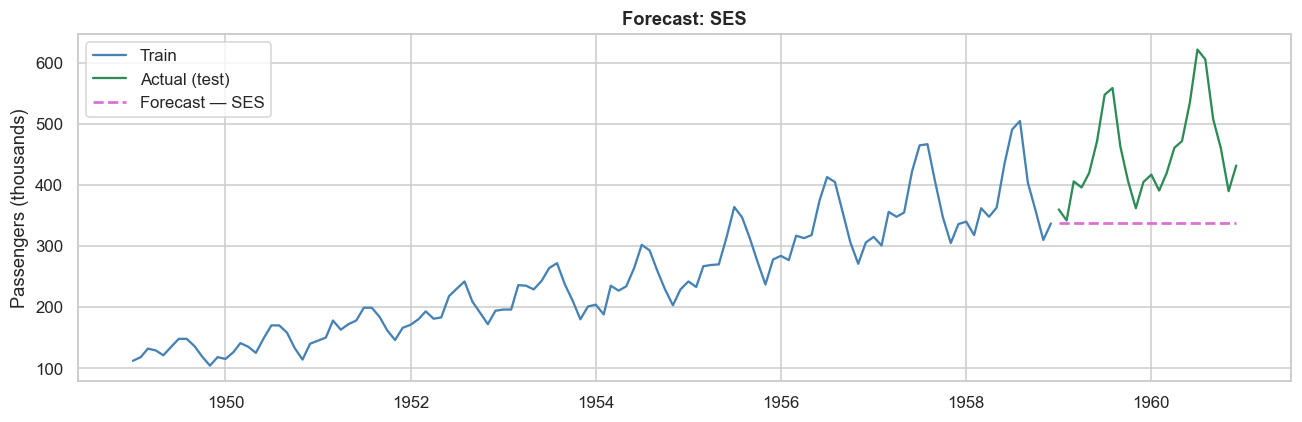

[SES]  MAE=115.25  RMSE=137.33  MAPE=23.58%


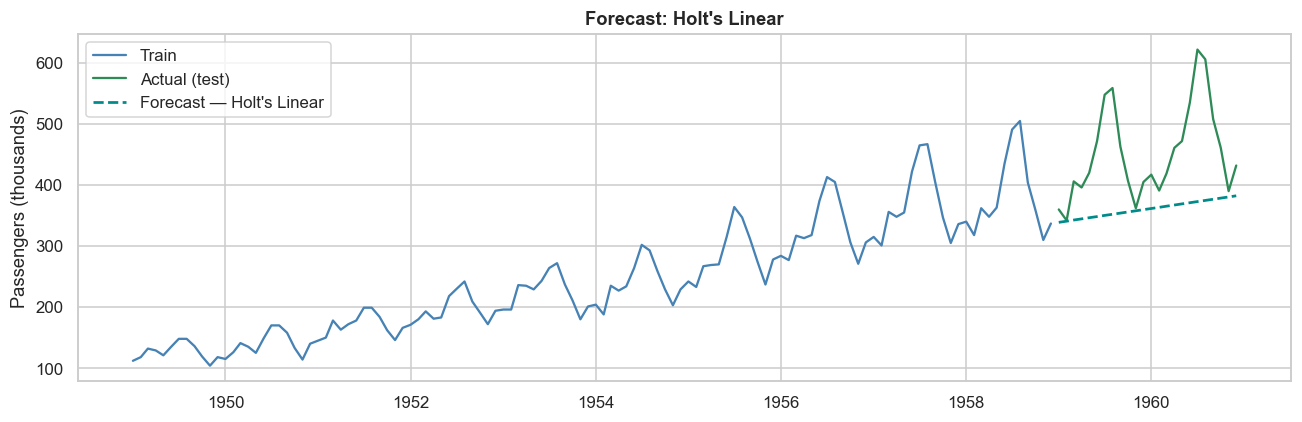

[Holt's Linear]  MAE=91.62  RMSE=115.70  MAPE=18.41%


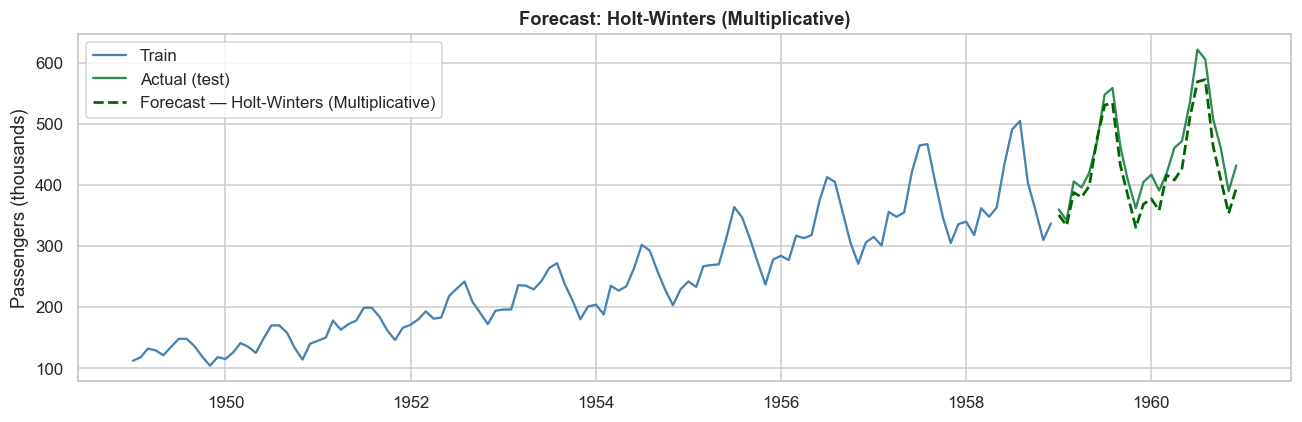

[Holt-Winters]  MAE=28.98  RMSE=32.49  MAPE=6.39%


In [12]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# ── SES ───────────────────────────────────────────────────────────────────────
ses_fit = SimpleExpSmoothing(train['Passengers']).fit(optimized=True)
ses_fc  = ses_fit.forecast(TEST_MONTHS)
ses_fc.index = test.index

plot_forecast('SES', train, test, ses_fc, color='orchid')
evaluate('SES', test['Passengers'], ses_fc)

# ── Holt (Double) ─────────────────────────────────────────────────────────────
holt_fit = ExponentialSmoothing(train['Passengers'], trend='add').fit(optimized=True)
holt_fc  = holt_fit.forecast(TEST_MONTHS)
holt_fc.index = test.index

plot_forecast("Holt's Linear", train, test, holt_fc, color='darkcyan')
evaluate("Holt's Linear", test['Passengers'], holt_fc)

# ── Holt-Winters (Triple, multiplicative) ─────────────────────────────────────
hw_fit = ExponentialSmoothing(train['Passengers'],
                               trend='add', seasonal='mul',
                               seasonal_periods=12).fit(optimized=True)
hw_fc = hw_fit.forecast(TEST_MONTHS)
hw_fc.index = test.index

plot_forecast('Holt-Winters (Multiplicative)', train, test, hw_fc, color='darkgreen')
evaluate('Holt-Winters', test['Passengers'], hw_fc)

### 6.4 Prophet (Meta/Facebook)

Prophet decomposes the time series as:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

- $g(t)$: **trend** — piecewise linear or logistic growth with automatic changepoint detection
- $s(t)$: **seasonality** — modelled with Fourier series of order $K$:
$$s(t) = \sum_{k=1}^{K}\left(a_k \cos\frac{2\pi k t}{P} + b_k \sin\frac{2\pi k t}{P}\right)$$
- $h(t)$: **holiday effects**

**Pros:** Robust to missing data, automatically detects changepoints, easy to tune.  
**Cons:** Less accurate when patterns are highly irregular; less interpretable than ARIMA.

04:58:06 - cmdstanpy - INFO - Chain [1] start processing
04:58:06 - cmdstanpy - INFO - Chain [1] done processing


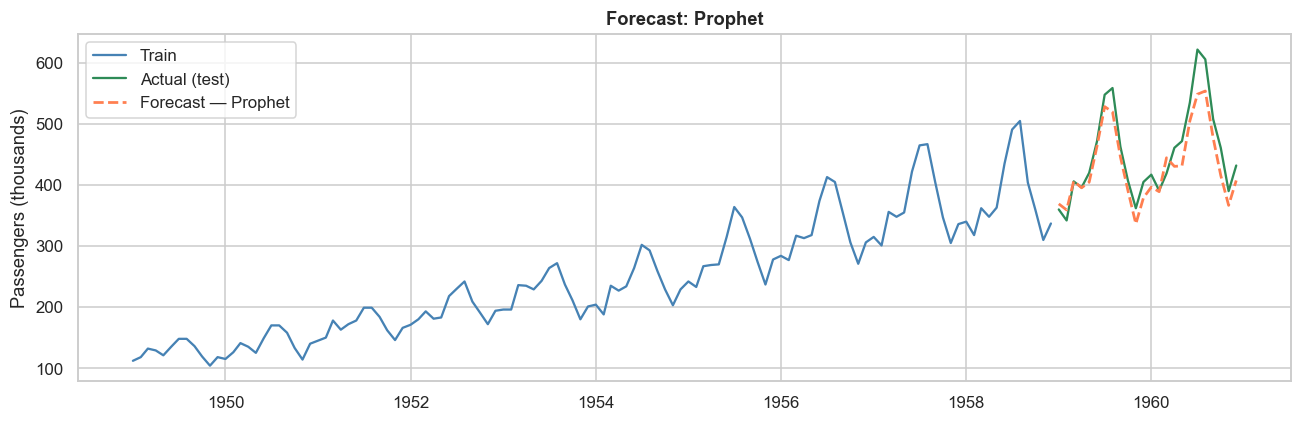

[Prophet]  MAE=24.65  RMSE=29.72  MAPE=5.21%


In [13]:
from prophet import Prophet

# Prophet requires columns 'ds' (date) and 'y' (value)
prophet_train = train.reset_index().rename(columns={'Month': 'ds', 'Passengers': 'y'})

prophet_model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True,
                        weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future    = prophet_model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
prophet_fc_df = prophet_model.predict(future)
prophet_fc = prophet_fc_df.set_index('ds')['yhat'].iloc[-TEST_MONTHS:]
prophet_fc.index = test.index

plot_forecast('Prophet', train, test, prophet_fc, color='coral')
evaluate('Prophet', test['Passengers'], prophet_fc)

---
## 7. Machine Learning Models

ML models do not natively understand time ordering. We **engineer lag features** and calendar features to convert the forecasting problem into a supervised regression task:

$$y_t = f(y_{t-1}, y_{t-2}, \ldots, y_{t-k}, \text{month}_t, \text{year}_t)$$

In [14]:
def make_lag_features(series, n_lags=13):
    """Create lag features + calendar features for ML models."""
    df_feat = pd.DataFrame({'y': series})
    for lag in range(1, n_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['y'].shift(lag)
    df_feat['month'] = df_feat.index.month
    df_feat['year']  = df_feat.index.year
    return df_feat.dropna()

feat_df = make_lag_features(df['Passengers'], n_lags=13)

# Align with train/test split
split_idx = feat_df.index.get_loc(test.index[0])
X_train_ml = feat_df.iloc[:split_idx].drop(columns='y')
y_train_ml = feat_df.iloc[:split_idx]['y']
X_test_ml  = feat_df.iloc[split_idx:split_idx + TEST_MONTHS].drop(columns='y')

print(f"X_train: {X_train_ml.shape}, X_test: {X_test_ml.shape}")

X_train: (107, 15), X_test: (24, 15)


### 7.1 LightGBM

LightGBM is a gradient boosting framework using **Gradient-based One-Side Sampling (GOSS)** and **Exclusive Feature Bundling (EFB)** for speed.

The objective is to minimise:
$$\mathcal{L} = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k)$$

where $\Omega(f) = \gamma T + \frac{1}{2}\lambda\|w\|^2$ is the regularisation term on tree leaves.

**Pros:** Very fast, handles large datasets, built-in feature importance.  
**Cons:** Requires careful feature engineering for temporal structure; can overfit with too many lags.

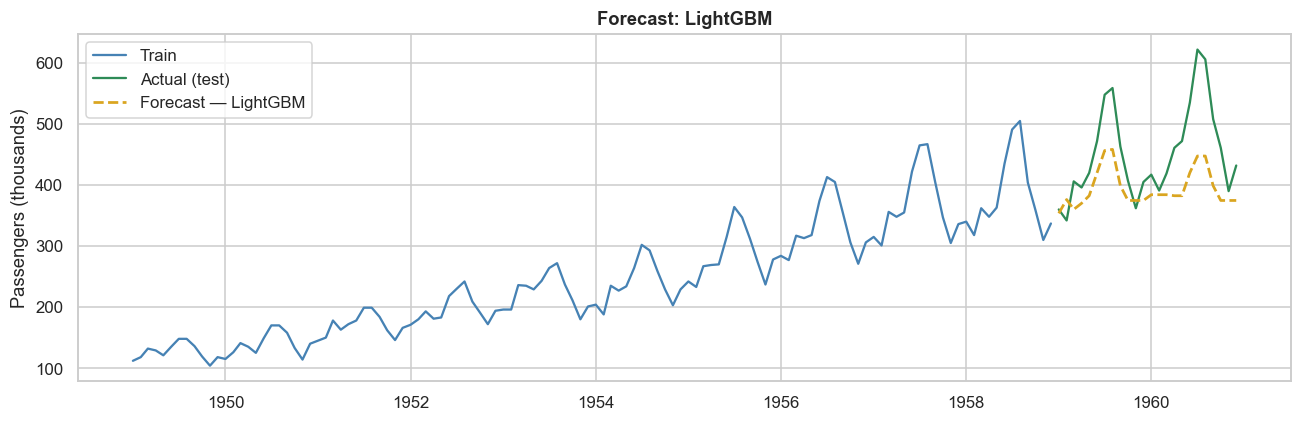

[LightGBM]  MAE=62.15  RMSE=76.64  MAPE=12.67%


In [15]:
# brew install libomp  # if on macOS and get "OMP: Error #15: Initializing libomp.dylib, but found libomp.dylib already initialized." error
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                               num_leaves=31, random_state=42, verbose=-1)
lgb_model.fit(X_train_ml, y_train_ml,
              eval_set=[(X_test_ml, test['Passengers'])],
              callbacks=[lgb.early_stopping(50, verbose=False)])

lgb_fc = pd.Series(lgb_model.predict(X_test_ml), index=test.index)

plot_forecast('LightGBM', train, test, lgb_fc, color='goldenrod')
evaluate('LightGBM', test['Passengers'], lgb_fc)

### 7.2 XGBoost

XGBoost also uses gradient boosting but with a **second-order Taylor expansion** of the loss to guide splits:

$$\mathcal{L}^{(t)} \approx \sum_i \left[g_i f_t(x_i) + \frac{1}{2}h_i f_t^2(x_i)\right] + \Omega(f_t)$$

where $g_i = \partial_{\hat{y}^{(t-1)}} l(y_i, \hat{y}^{(t-1)})$ and $h_i$ is the second derivative.

**Pros:** Robust regularisation; handles missing values natively.  
**Cons:** Slower than LightGBM on large datasets; same temporal limitation.

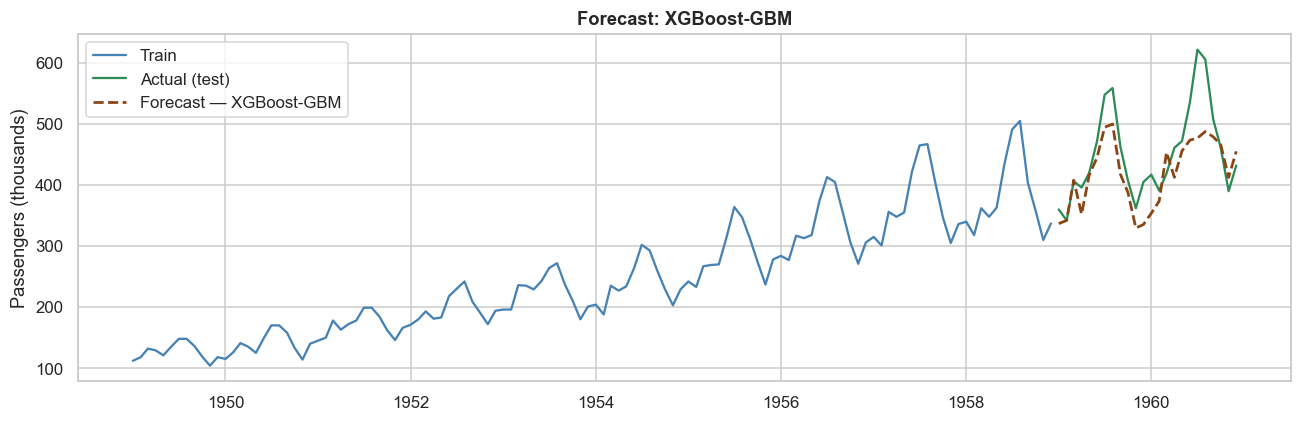

[XGBoost-GBM]  MAE=40.12  RMSE=52.71  MAPE=8.32%


In [16]:
from sklearn.ensemble import GradientBoostingRegressor
# Using sklearn's GBM (same family as XGBoost, no extra install needed)
# Replace with xgb.XGBRegressor if xgboost is installed

xgb_model = GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                       max_depth=4, random_state=42)
xgb_model.fit(X_train_ml, y_train_ml)

xgb_fc = pd.Series(xgb_model.predict(X_test_ml), index=test.index)

plot_forecast('XGBoost-GBM', train, test, xgb_fc, color='saddlebrown')
evaluate('XGBoost-GBM', test['Passengers'], xgb_fc)

---
## 8. Deep Learning Models

### Data Preparation for Sequence Models

Deep learning models take fixed-length **input windows** $(y_{t-w}, \ldots, y_{t-1})$ and predict one step ahead. We normalise with a Min-Max scaler.

In [17]:
from sklearn.preprocessing import MinMaxScaler

WINDOW = 24   # look-back window (months)

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train[['Passengers']])

def make_sequences(arr, window):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i - window:i, 0])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_dl, y_dl = make_sequences(train_scaled, WINDOW)
X_dl = X_dl.reshape(X_dl.shape[0], X_dl.shape[1], 1)
last_window_scaled = train_scaled[-WINDOW:, 0]

print(f"X shape: {X_dl.shape}, y shape: {y_dl.shape}")


X shape: (96, 24, 1), y shape: (96,)


In [18]:
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

# scaler, WINDOW, X_dl, y_dl and last_window_scaled defined above
print("TensorFlow", tf.__version__, "ready.")


TensorFlow 2.16.2 ready.


In [19]:
def recursive_forecast(model, last_window, n_steps, scaler):
    """Recursively forecast n_steps ahead using a trained Keras model."""
    preds = []
    window = last_window.copy()
    for _ in range(n_steps):
        x = window.reshape(1, len(window), 1)
        pred = model.predict(x, verbose=0)[0, 0]
        preds.append(pred)
        window = np.append(window[1:], pred)
    return scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

last_window_scaled = train_scaled[-WINDOW:, 0]

### 8.1 Simple RNN

A **Recurrent Neural Network** processes sequences by maintaining a hidden state $h_t$:

$$h_t = \tanh(W_h h_{t-1} + W_x x_t + b)$$
$$\hat{y}_t = W_y h_t + b_y$$

**Pros:** Captures sequential dependencies; simple architecture.  
**Cons:** **Vanishing gradient problem** — struggles with long-range dependencies (sequences > ~10 steps).


2026-05-05 04:58:10.275664: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-05 04:58:10.275698: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-05 04:58:10.275704: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-05 04:58:10.275718: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-05 04:58:10.275728: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

2026-05-05 04:58:10.647307: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


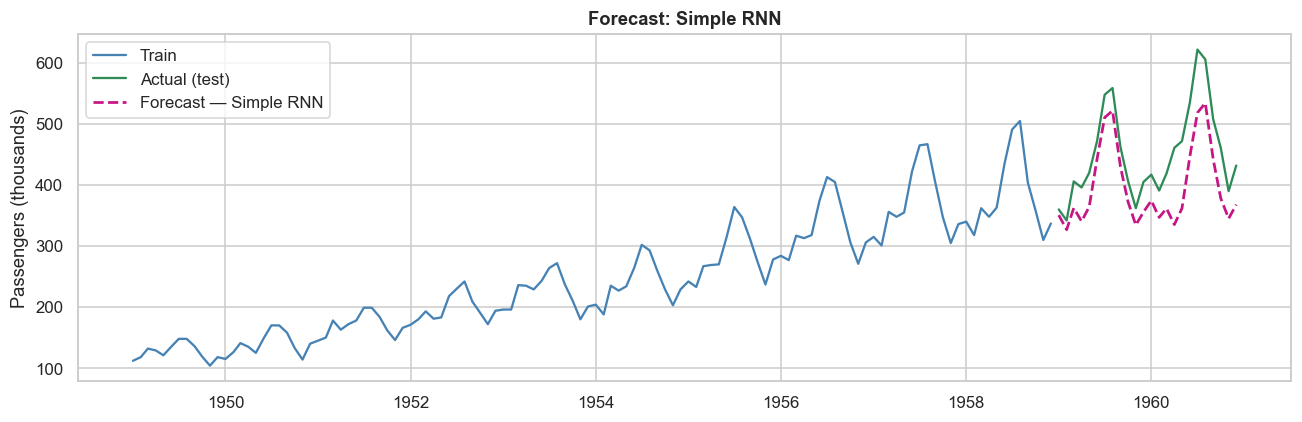

[RNN]  MAE=55.28  RMSE=62.35  MAPE=11.99%


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

rnn_model = Sequential([
    SimpleRNN(32, input_shape=(WINDOW, 1), return_sequences=False),
    Dense(1)
], name='SimpleRNN')

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.summary()

rnn_model.fit(X_dl, y_dl, epochs=100, batch_size=16, verbose=0,
              callbacks=[early_stop])

rnn_fc = recursive_forecast(rnn_model, last_window_scaled, TEST_MONTHS, scaler)
rnn_fc = pd.Series(rnn_fc, index=test.index)

plot_forecast('Simple RNN', train, test, rnn_fc, color='mediumvioletred')
evaluate('RNN', test['Passengers'], rnn_fc)

### 8.2 LSTM — Long Short-Term Memory

LSTM solves the vanishing gradient problem via **gating mechanisms** that selectively remember or forget information:

$$f_t = \sigma(W_f [h_{t-1}, x_t] + b_f) \quad \text{(forget gate)}$$
$$i_t = \sigma(W_i [h_{t-1}, x_t] + b_i) \quad \text{(input gate)}$$
$$\tilde{C}_t = \tanh(W_C [h_{t-1}, x_t] + b_C) \quad \text{(candidate memory)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t \quad \text{(cell state update)}$$
$$o_t = \sigma(W_o [h_{t-1}, x_t] + b_o) \quad \text{(output gate)}$$
$$h_t = o_t \odot \tanh(C_t)$$

**Pros:** Captures long-range dependencies; handles non-linear patterns.  
**Cons:** More parameters than RNN; slower to train; needs enough data.


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

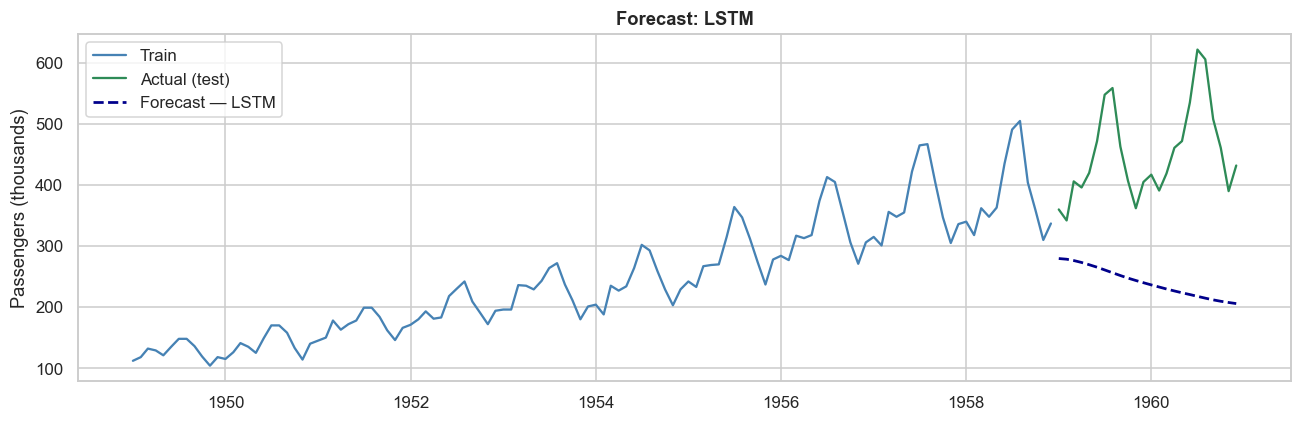

[LSTM]  MAE=211.47  RMSE=228.62  MAPE=45.05%


In [21]:
lstm_model = Sequential([
    LSTM(64, input_shape=(WINDOW, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dense(1)
], name='LSTM')

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

lstm_model.fit(X_dl, y_dl, epochs=150, batch_size=16, verbose=0,
               callbacks=[early_stop])

lstm_fc = recursive_forecast(lstm_model, last_window_scaled, TEST_MONTHS, scaler)
lstm_fc = pd.Series(lstm_fc, index=test.index)

plot_forecast('LSTM', train, test, lstm_fc, color='darkblue')
evaluate('LSTM', test['Passengers'], lstm_fc)

---
### 8.3 Temporal Fusion Transformer (TFT)

The **Temporal Fusion Transformer** (Lim et al., 2021) is a state-of-the-art attention-based architecture for multi-horizon time-series forecasting.

### Mathematical Background

The core attention mechanism (scaled dot-product):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

TFT key components:

1. **Gated Residual Networks (GRN)** — adaptive non-linear processing with gating:
$$\text{GRN}(a) = \text{LayerNorm}\left(a + \text{GLU}(\eta_1)\right), \quad \eta_1 = W_1 \text{ELU}(W_2 a + b_2) + b_1$$

2. **Variable Selection Networks** — learn which input variables are most important.

3. **Multi-head Self-Attention** — captures temporal dependencies across multiple scales.

4. **Quantile outputs** — TFT natively produces prediction intervals (e.g., 10th, 50th, 90th percentile).

**Pros:** Interpretable attention weights; handles known future inputs (e.g., holidays, promotions); produces calibrated uncertainty intervals.  
**Cons:** Requires more data than classical models; computationally heavier.


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

# Selección automática de dispositivo — MPS (Apple Silicon), CUDA, o CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f"Usando: {DEVICE}")

TFT_WINDOW = 24
TFT_PRED   = TEST_MONTHS

# ── Secuencias ────────────────────────────────────────────────────────────────
def tft_sequences(arr, enc_len, pred_len):
    X_enc, X_month, y_out = [], [], []
    for i in range(enc_len, len(arr) - pred_len + 1):
        X_enc.append(arr[i - enc_len:i, 0])
        future_months = np.arange(i, i + pred_len) % 12 / 11.0
        X_month.append(future_months)
        y_out.append(arr[i:i + pred_len, 0])
    return (torch.tensor(np.array(X_enc),   dtype=torch.float32).unsqueeze(-1).to(DEVICE),
            torch.tensor(np.array(X_month), dtype=torch.float32).unsqueeze(-1).to(DEVICE),
            torch.tensor(np.array(y_out),   dtype=torch.float32).to(DEVICE))

X_enc, X_dec, y_tft = tft_sequences(train_scaled, TFT_WINDOW, TFT_PRED)
print(f"Encoder: {X_enc.shape}  Decoder: {X_dec.shape}  Target: {y_tft.shape}")

# ── Modelo ────────────────────────────────────────────────────────────────────
class GRN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1  = nn.Linear(d, d)
        self.fc2  = nn.Linear(d, d)
        self.gate = nn.Linear(d, d)
        self.norm = nn.LayerNorm(d)
    def forward(self, x):
        h = torch.relu(self.fc1(x))
        h = self.fc2(h)
        g = torch.sigmoid(self.gate(x))
        return self.norm(x + g * h)

class SimpleTFT(nn.Module):
    def __init__(self, d_model=16, pred_len=24):
        super().__init__()
        self.enc_embed = nn.Linear(1, d_model)
        self.enc_lstm  = nn.LSTM(d_model, d_model, batch_first=True)
        self.dec_embed = nn.Linear(1, d_model)
        self.grn       = GRN(d_model)
        self.head      = nn.Linear(d_model, 3)   # q10, q50, q90

    def forward(self, x_enc, x_dec):
        enc_out, _ = self.enc_lstm(self.enc_embed(x_enc))
        d = self.dec_embed(x_dec)
        context = enc_out.mean(dim=1, keepdim=True).expand_as(d)
        return self.head(self.grn(context + d))

def quantile_loss(preds, target, quantiles=(0.1, 0.5, 0.9)):
    losses = [torch.max(q * (target - preds[..., i]),
                        (q - 1) * (target - preds[..., i]))
              for i, q in enumerate(quantiles)]
    return torch.mean(torch.stack(losses))

# ── Entrenamiento ─────────────────────────────────────────────────────────────
tft_net   = SimpleTFT(d_model=16, pred_len=TFT_PRED).to(DEVICE)
optimiser = optim.Adam(tft_net.parameters(), lr=1e-3)

tft_net.train()
for epoch in range(40):
    epoch_loss = 0.0
    for i in range(0, len(X_enc), 8):
        xb_enc, xb_dec, yb = X_enc[i:i+8], X_dec[i:i+8], y_tft[i:i+8]
        optimiser.zero_grad()
        loss = quantile_loss(tft_net(xb_enc, xb_dec), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(tft_net.parameters(), 0.5)
        optimiser.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss:.4f}")

print(f"\nTFT parámetros: {sum(p.numel() for p in tft_net.parameters()):,}")


Usando: mps
Encoder: torch.Size([73, 24, 1])  Decoder: torch.Size([73, 24, 1])  Target: torch.Size([73, 24])
Epoch  10 | Loss: 0.4889
Epoch  20 | Loss: 0.3645
Epoch  30 | Loss: 0.2707
Epoch  40 | Loss: 0.2492

TFT parámetros: 3,139


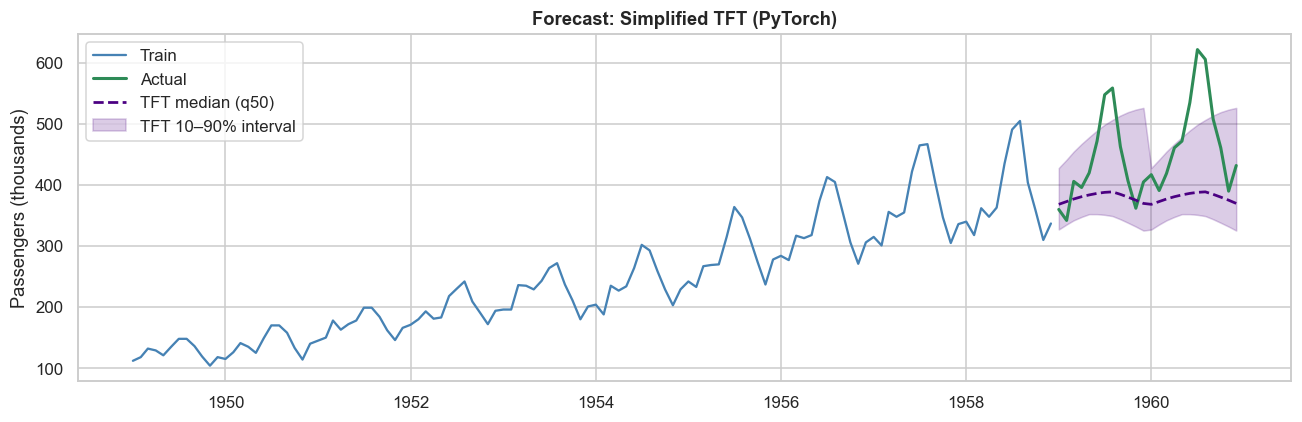

[TFT]  MAE=76.92  RMSE=100.40  MAPE=15.33%


In [23]:
# ── Forecast ─────────────────────────────────────────────────────────────────
tft_net.eval()
with torch.no_grad():
    enc_input = torch.tensor(
        train_scaled[-TFT_WINDOW:, 0], dtype=torch.float32
    ).unsqueeze(0).unsqueeze(-1).to(DEVICE)   # (1, 24, 1)

    last_idx      = len(train_scaled)
    future_months = np.arange(last_idx, last_idx + TFT_PRED) % 12 / 11.0
    dec_input = torch.tensor(future_months, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(DEVICE)

    tft_out = tft_net(enc_input, dec_input).cpu()   # (1, 24, 3) → CPU para numpy

tft_median = scaler.inverse_transform(tft_out[0, :, 1].numpy().reshape(-1, 1)).flatten()
tft_lo     = scaler.inverse_transform(tft_out[0, :, 0].numpy().reshape(-1, 1)).flatten()
tft_hi     = scaler.inverse_transform(tft_out[0, :, 2].numpy().reshape(-1, 1)).flatten()

tft_fc = pd.Series(tft_median, index=test.index)

plt.figure(figsize=(12, 4))
plt.plot(train.index, train['Passengers'], color='steelblue', lw=1.5, label='Train')
plt.plot(test.index,  test['Passengers'],  color='seagreen',  lw=2,   label='Actual')
plt.plot(test.index,  tft_fc,             color='indigo',    lw=1.8, ls='--', label='TFT median (q50)')
plt.fill_between(test.index, tft_lo, tft_hi, alpha=0.2, color='indigo', label='TFT 10–90% interval')
plt.title('Forecast: Simplified TFT (PyTorch)', fontsize=12, fontweight='bold')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.tight_layout()
plt.show()

evaluate('TFT', test['Passengers'], tft_fc)


---
## 10. Results Comparison

### Metrics Summary Table

In [24]:
results_df = (pd.DataFrame(results_list)
              .drop_duplicates(subset='Model', keep='last')  # remove duplicates from re-runs
              .set_index('Model')
              .sort_values('RMSE'))
results_df.index.name = 'Model'

# Highlight best in each column
styled = results_df.style\
    .highlight_min(color='lightgreen', axis=0)\
    .format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'MAPE (%)': '{:.2f}'})\
    .set_caption('Model Comparison — Test Set (last 24 months). Lower is better. Best highlighted in green.')

display(styled)

,MAE,RMSE,MAPE (%)
Model,,,
Prophet,24.65,29.72,5.21
Holt-Winters,28.98,32.49,6.39
XGBoost-GBM,40.12,52.71,8.32
RNN,55.28,62.35,11.99
SARIMA,69.90,75.63,15.22
LightGBM,62.15,76.64,12.67
ARIMA,69.10,90.69,13.78
TFT,76.92,100.40,15.33
Holt's Linear,91.62,115.70,18.41


### Visual Comparison

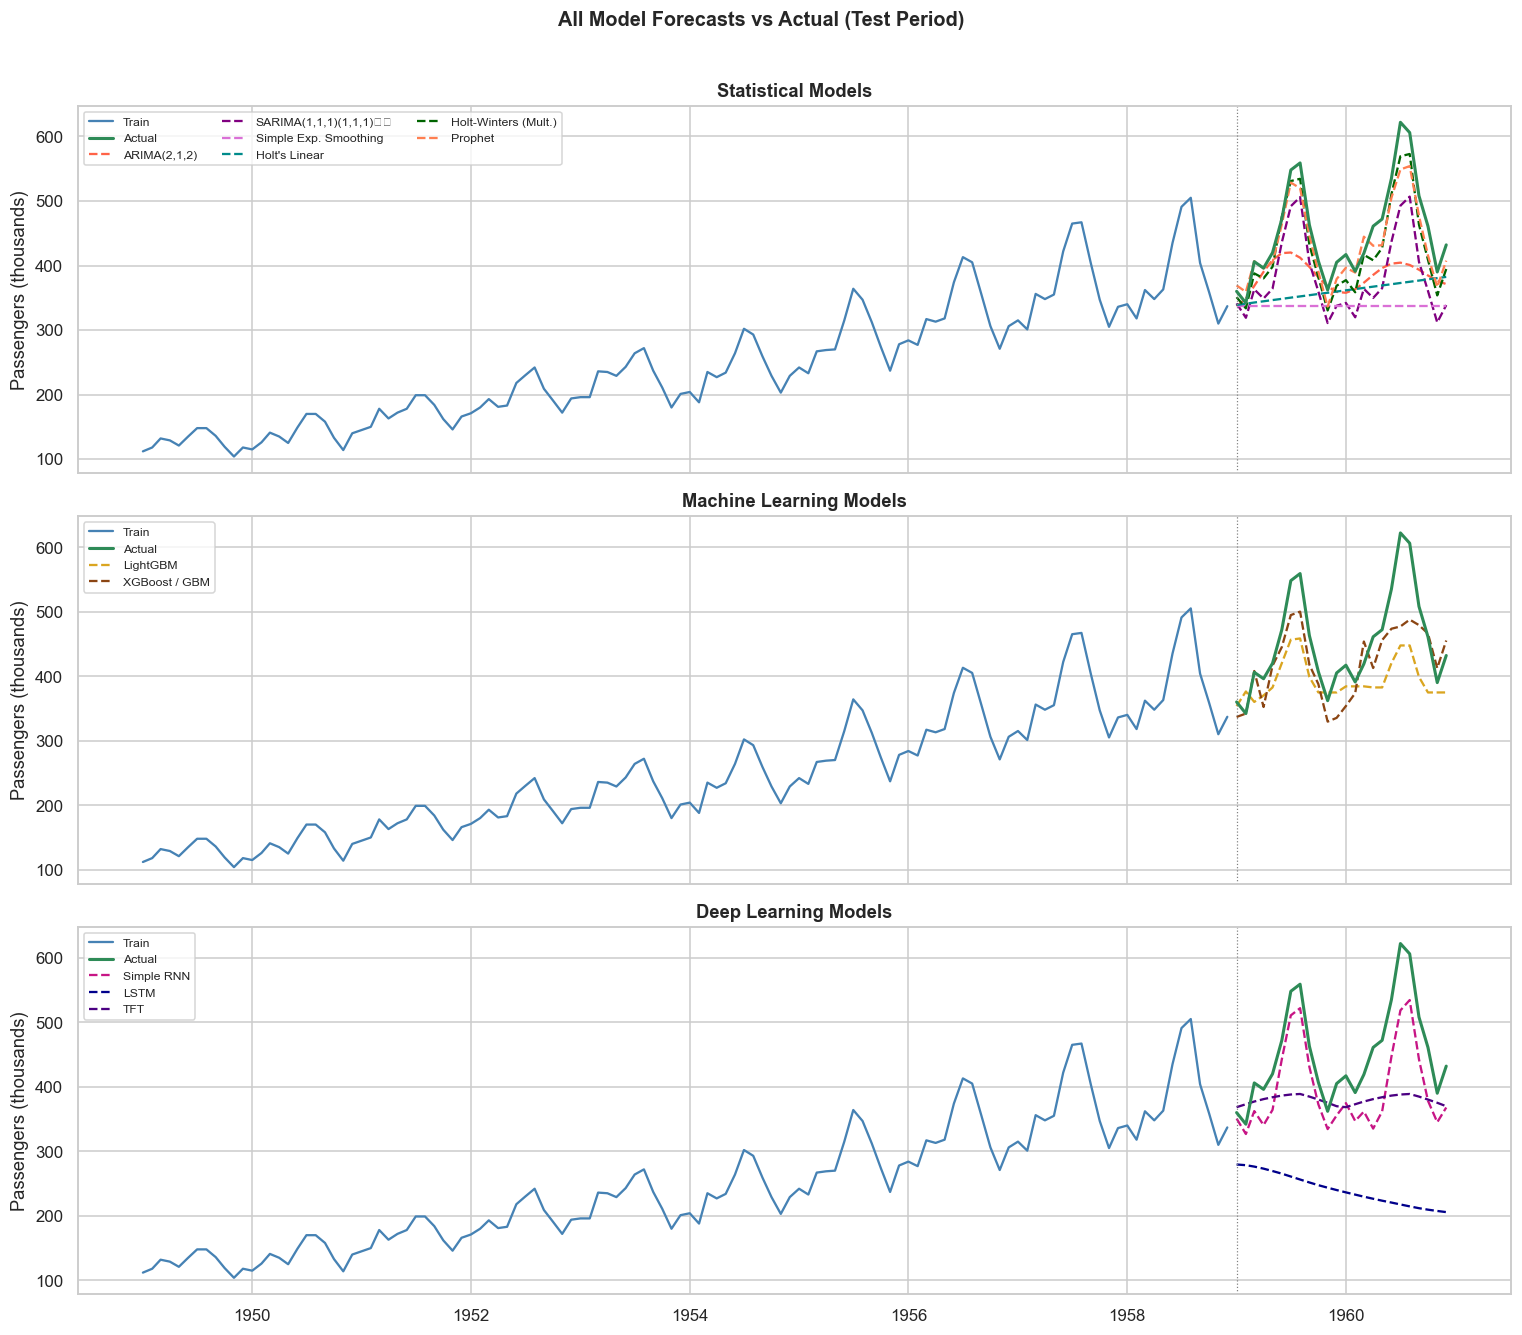

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

color_map = {
    'ARIMA':       ('tomato',          'ARIMA(2,1,2)'),
    'SARIMA':      ('purple',          'SARIMA(1,1,1)(1,1,1)₁₂'),
    'SES':         ('orchid',          'Simple Exp. Smoothing'),
    "Holt's Linear": ('darkcyan',      "Holt's Linear"),
    'Holt-Winters': ('darkgreen',      'Holt-Winters (Mult.)'),
    'Prophet':     ('coral',           'Prophet'),
}
ml_map = {
    'LightGBM':    ('goldenrod',       'LightGBM'),
    'XGBoost/GBM': ('saddlebrown',     'XGBoost / GBM'),
}
dl_map = {
    'RNN':         ('mediumvioletred', 'Simple RNN'),
    'LSTM':        ('darkblue',        'LSTM'),
    'TFT':         ('indigo',          'TFT'),
}

# Actual
for ax in axes:
    ax.plot(train.index, train['Passengers'], color='steelblue', lw=1.5, label='Train')
    ax.plot(test.index,  test['Passengers'],  color='seagreen',  lw=2,   label='Actual', zorder=5)

# Build forecast series lookup from results_list (we stored them in variables)
# We'll re-use the forecast variables directly
forecasts = {
    'ARIMA':        arima_forecast,
    'SARIMA':       sarima_forecast,
    'SES':          ses_fc,
    "Holt's Linear": holt_fc,
    'Holt-Winters': hw_fc,
    'Prophet':      prophet_fc,
    'LightGBM':     lgb_fc,
    'XGBoost/GBM':  xgb_fc,
    'RNN':          rnn_fc,
    'LSTM':         lstm_fc,
    'TFT':          tft_fc,
}

for name, (color, label) in color_map.items():
    axes[0].plot(test.index, forecasts[name], color=color, lw=1.5, ls='--', label=label)
axes[0].set_title('Statistical Models', fontweight='bold')
axes[0].legend(fontsize=8, ncol=3)

for name, (color, label) in ml_map.items():
    axes[1].plot(test.index, forecasts[name], color=color, lw=1.5, ls='--', label=label)
axes[1].set_title('Machine Learning Models', fontweight='bold')
axes[1].legend(fontsize=8)

for name, (color, label) in dl_map.items():
    axes[2].plot(test.index, forecasts[name], color=color, lw=1.5, ls='--', label=label)
axes[2].set_title('Deep Learning Models', fontweight='bold')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_ylabel('Passengers (thousands)')
    ax.axvline(test.index[0], color='grey', ls=':', lw=0.8)

plt.suptitle('All Model Forecasts vs Actual (Test Period)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_forecasts_comparison.png', bbox_inches='tight')
plt.show()

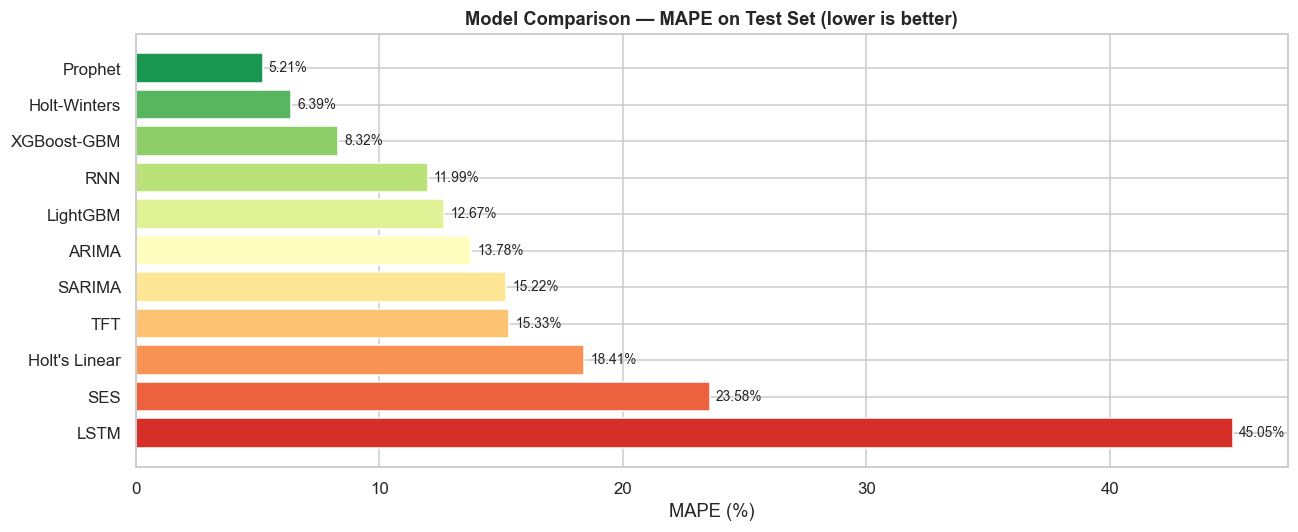

In [26]:
# ── Bar chart of MAPE ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
sorted_df = results_df.sort_values('MAPE (%)')
bars = ax.barh(sorted_df.index, sorted_df['MAPE (%)'],
               color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sorted_df))))
ax.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=9)
ax.set_xlabel('MAPE (%)')
ax.set_title('Model Comparison — MAPE on Test Set (lower is better)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('mape_comparison.png', bbox_inches='tight')
plt.show()

## 11. Model Selection Guide

| Model | Best for | Pros | Cons |
|---|---|---|---|
| **ARIMA** | Short-term, stationary data | Simple, interpretable | No seasonality; assumes linearity |
| **SARIMA** | Seasonal univariate series | Handles seasonality | Many hyperparameters to tune |
| **SES** | Level-only data | Extremely fast | No trend or seasonality |
| **Holt's Linear** | Trending data | Adds trend component | No seasonality |
| **Holt-Winters** | Seasonal + trend | Handles both; fast | Assumes fixed seasonal pattern |
| **Prophet** | Business time series with holidays | Robust; auto changepoints; handles missing data | Less accurate with irregular patterns |
| **LightGBM** | Large datasets, fast inference | Very fast; feature importance | Needs lag engineering; no temporal ordering |
| **XGBoost/GBM** | Tabular + temporal features | Strong regularisation | Slower than LGBM; same limitations |
| **RNN** | Short sequences | Simple sequential model | Vanishing gradients; poor long-range memory |
| **LSTM** | Non-linear, long-range dependencies | Solves vanishing gradient; strong pattern capture | Data-hungry; computationally heavy |
| **TFT** | Multi-horizon + known future inputs | Interpretable attention; calibrated intervals | Most complex; needs most data |

### When to Use Which Model

```
Short-term & simple patterns      → ARIMA / Holt-Winters
Clear seasonality                 → SARIMA / Prophet / Holt-Winters
Business data + holidays          → Prophet
Large datasets, speed critical    → LightGBM / XGBoost
Non-linear, enough data           → LSTM
Multi-horizon + uncertainty       → TFT
```

---
## 12. Practice Activity

1. **Change the test window** — try `TEST_MONTHS = 12` or `36` and observe how each model degrades.
2. **Tune SARIMA** — use `auto_arima` from `pmdarima` to find optimal $(p,d,q)(P,D,Q)_{12}$.
3. **Feature engineering** — add Fourier features (sin/cos of month) to the ML models.
4. **Log transformation** — apply `np.log` before modelling and `np.exp` after; observe the effect on MAPE.
5. **Multivariate** — find a dataset with additional features (e.g., fuel price, GDP) and adapt SARIMAX or TFT.

___
### **References:**

[1] *Manu Joseph*, and *Jeffrey Tackes*, **Modern Time Series Forecasting with Python: Industry-ready machine learning and deep learning time series analysis with PyTorch and pandas**, Second Edition, Packt Publishing Ltd.  

[![Open in GitHub](https://img.shields.io/badge/Open%20in-GitHub-181717?logo=github)](https://github.com/PacktPublishing/Modern-Time-Series-Forecasting-with-Python-2E)